In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("feature_engineered_accidents.csv")

C:\Users\klarikach\AppData\Local\Temp\ipykernel_29080\661840092.py:4: DtypeWarning: Columns (0: collision_index, 1: collision_ref_no) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("feature_engineered_accidents.csv")


In [23]:
df.shape

(513748, 53)

In [24]:
df.head()

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,collision_adjusted_severity_slight,year,month,month_name,day,weekday,quarter,hour,time_bucket,is_weekend
0,202517M102225,2025,17M102225,449804.0,519612.0,-1.23119,54.56929,17,3,1,...,1.0,2025,2,February,15,Saturday,1,19,Evening,True
1,202417S111924,2024,17S111924,444670.0,520502.0,-1.31046,54.57776,17,2,1,...,0.0,2024,10,October,22,Tuesday,4,14,Afternoon,False
2,2025111687011,2025,111687011,427772.0,515144.0,-1.57237,54.53082,11,3,2,...,1.0,2025,12,December,19,Friday,4,6,Morning,False
3,2025070326701,2025,070326701,351585.0,382993.0,-2.72862,53.34161,7,1,1,...,0.0,2025,4,April,22,Tuesday,2,20,Evening,False
4,2025070353559,2025,070353559,351101.0,382954.0,-2.73589,53.34121,7,3,2,...,1.0,2025,4,April,28,Monday,2,17,Evening,False


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 513748 entries, 0 to 513747
Data columns (total 53 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   513748 non-null  object 
 1   collision_year                                    513748 non-null  int64  
 2   collision_ref_no                                  513748 non-null  object 
 3   location_easting_osgr                             513748 non-null  float64
 4   location_northing_osgr                            513748 non-null  float64
 5   longitude                                         513748 non-null  float64
 6   latitude                                          513748 non-null  float64
 7   police_force                                      513748 non-null  int64  
 8   collision_severity                                513748 non-null  int64  
 9   number_of_vehic

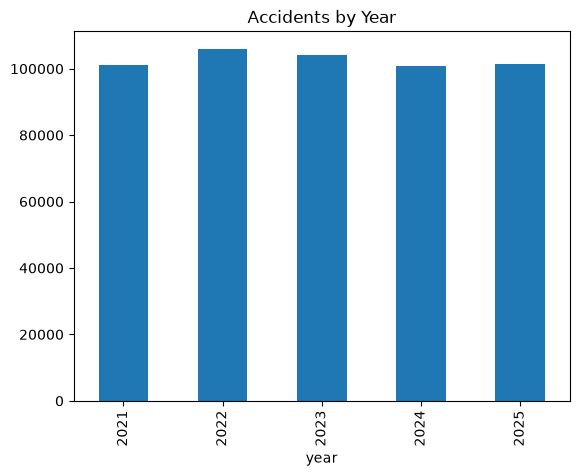

In [26]:
accidents_year = df.groupby('year').size()

accidents_year.plot(kind='bar')
plt.title('Accidents by Year')
plt.show()

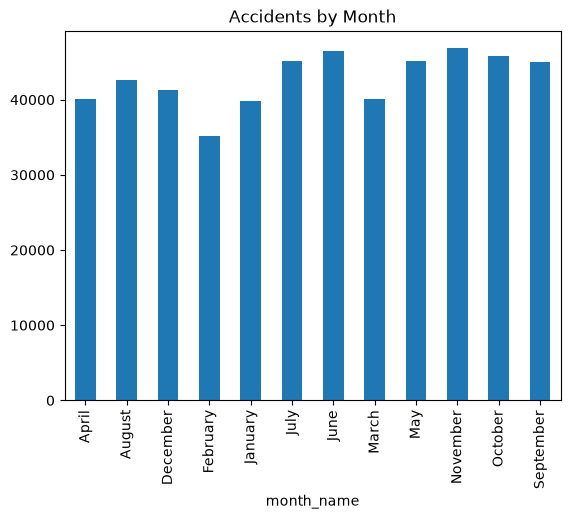

In [27]:
accidents_month = df.groupby('month_name').size()

accidents_month.plot(kind='bar')
plt.title('Accidents by Month')
plt.show()

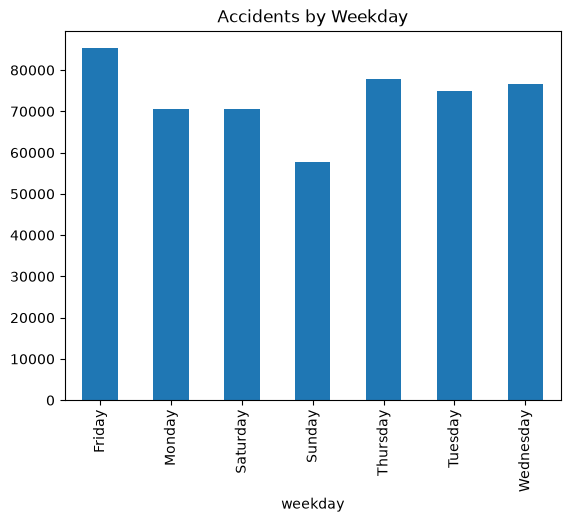

In [28]:
accidents_weekday = df.groupby('weekday').size()

accidents_weekday.plot(kind='bar')
plt.title('Accidents by Weekday')
plt.show()

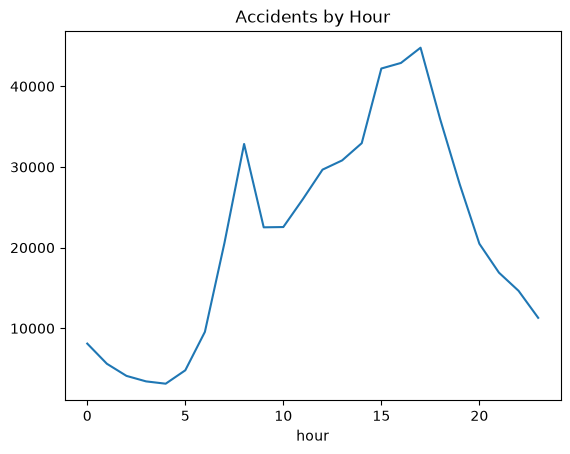

In [29]:
accidents_hour = df.groupby('hour').size()

accidents_hour.plot()
plt.title('Accidents by Hour')
plt.show()

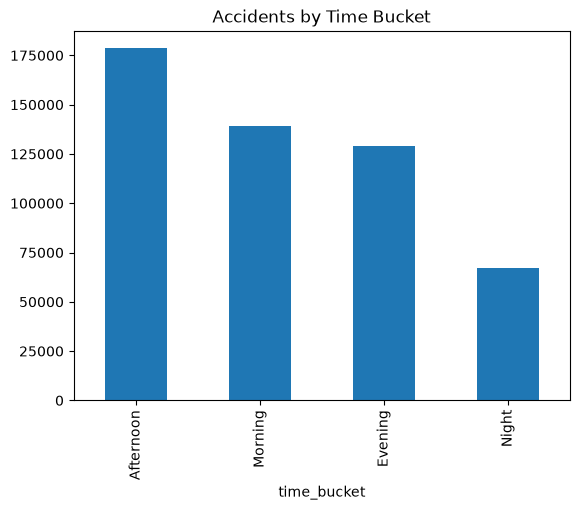

In [30]:
df['time_bucket'].value_counts().plot(
    kind='bar'
)

plt.title('Accidents by Time Bucket')
plt.show()

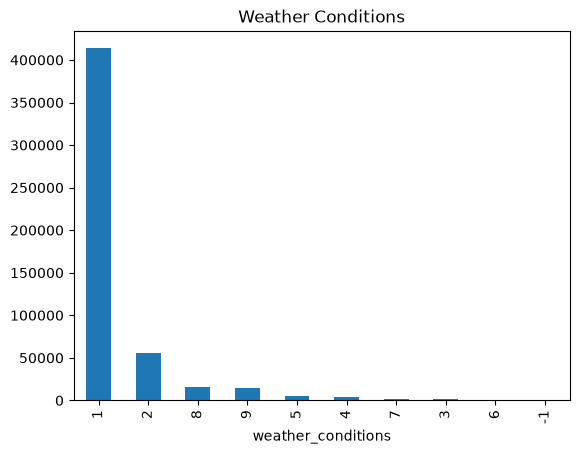

In [31]:
df['weather_conditions'].value_counts().plot(
    kind='bar'
)

plt.title('Weather Conditions')
plt.show()

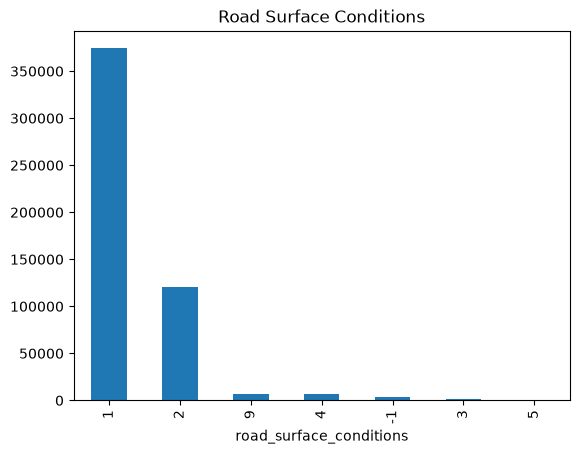

In [32]:
df['road_surface_conditions'].value_counts().plot(
    kind='bar'
)

plt.title('Road Surface Conditions')
plt.show()

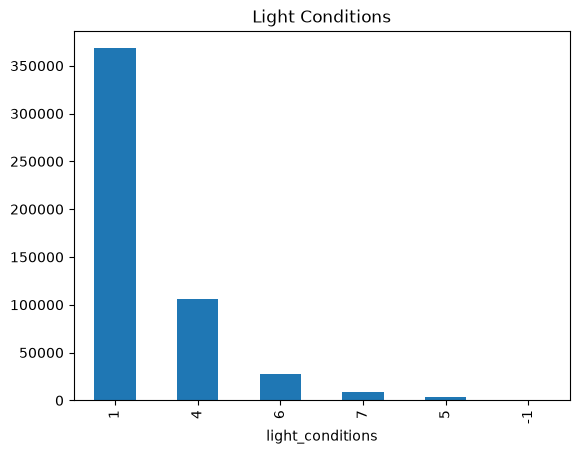

In [33]:
df['light_conditions'].value_counts().plot(
    kind='bar'
)

plt.title('Light Conditions')
plt.show()

In [34]:
df.columns.tolist()

['collision_index',
 'collision_year',
 'collision_ref_no',
 'location_easting_osgr',
 'location_northing_osgr',
 'longitude',
 'latitude',
 'police_force',
 'collision_severity',
 'number_of_vehicles',
 'number_of_casualties',
 'date',
 'day_of_week',
 'time',
 'local_authority_district',
 'local_authority_ons_district',
 'local_authority_highway',
 'local_authority_highway_current',
 'first_road_class',
 'first_road_number',
 'road_type',
 'speed_limit',
 'junction_detail_historic',
 'junction_detail',
 'junction_control',
 'second_road_class',
 'second_road_number',
 'pedestrian_crossing_human_control_historic',
 'pedestrian_crossing_physical_facilities_historic',
 'pedestrian_crossing',
 'light_conditions',
 'weather_conditions',
 'road_surface_conditions',
 'special_conditions_at_site',
 'carriageway_hazards_historic',
 'carriageway_hazards',
 'urban_or_rural_area',
 'did_police_officer_attend_scene_of_accident',
 'trunk_road_flag',
 'lsoa_of_accident_location',
 'enhanced_severit

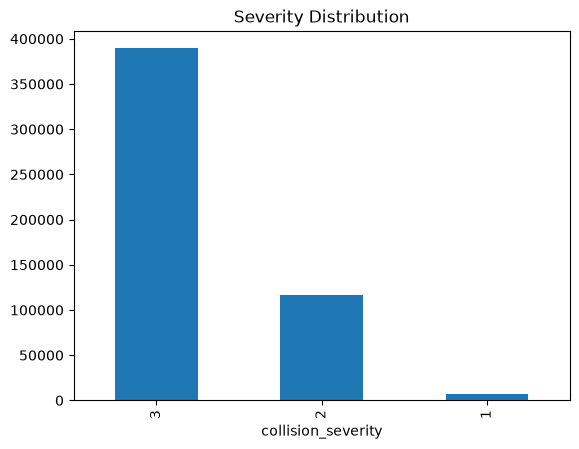

In [35]:


df['collision_severity'].value_counts().plot(
    kind='bar'
)

plt.title('Severity Distribution')
plt.show()

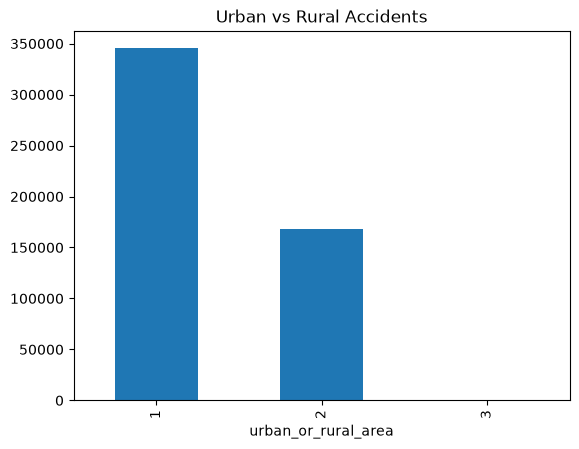

In [36]:
df['urban_or_rural_area'].value_counts().plot(
    kind='bar'
)

plt.title('Urban vs Rural Accidents')
plt.show()

In [37]:
df['first_road_class'].value_counts().head(10)

first_road_class
 3    225810
 6    184187
 4     64446
 5     22611
 1     15450
 2      1239
-1         5
Name: count, dtype: int64

In [38]:
df['junction_control'].value_counts().head(10)

junction_control
 4    222540
-1    217877
 2     56427
 9     11210
 3      3484
 1      2210
Name: count, dtype: int64

In [39]:
df['junction_detail'].value_counts().head(10)

junction_detail
 0     251994
 13    142579
 16     47570
 19     31093
-1      19982
 18     11144
 17      7957
 99      1429
Name: count, dtype: int64

In [40]:
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()
corr

,collision_year,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,day_of_week,...,trunk_road_flag,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight,year,month,day,quarter,hour
collision_year,1.000000,-0.007931,0.007738,-0.007725,0.007773,0.012670,-0.026079,-0.014781,-0.004817,-0.005270,...,0.001631,0.206352,0.230133,0.024236,-0.023463,1.000000,-0.029883,-0.004298,-0.030024,-0.003038
location_easting_osgr,-0.007931,1.000000,-0.402415,0.999468,-0.405116,-0.339771,0.072002,0.032011,-0.043843,0.004159,...,0.472764,-0.099912,-0.094538,-0.081425,0.089924,-0.007931,-0.001943,-0.000752,-0.001575,-0.004412
location_northing_osgr,0.007738,-0.402415,1.000000,-0.409404,0.999968,0.103642,-0.102835,-0.029064,0.040287,-0.002074,...,-0.402124,0.277952,0.282463,0.094233,-0.104121,0.007738,0.002047,0.001398,0.001065,0.008601
longitude,-0.007725,0.999468,-0.409404,1.000000,-0.412028,-0.349621,0.073426,0.032288,-0.043561,0.004197,...,0.486834,-0.101132,-0.095094,-0.082495,0.091044,-0.007725,-0.001969,-0.000836,-0.001594,-0.004602
latitude,0.007773,-0.405116,0.999968,-0.412028,1.000000,0.101999,-0.102678,-0.029014,0.040234,-0.002081,...,-0.400518,0.276676,0.281065,0.094188,-0.104064,0.007773,0.002042,0.001377,0.001064,0.008651
police_force,0.012670,-0.339771,0.103642,-0.349621,0.101999,1.000000,-0.087358,-0.005872,0.059142,-0.003810,...,-0.625539,0.215545,0.226662,0.085047,-0.095328,0.012670,0.003583,0.001662,0.003889,-0.016712
collision_severity,-0.026079,0.072002,-0.102835,0.073426,-0.102678,-0.087358,1.000000,0.063018,-0.090912,0.000793,...,0.083693,-0.352634,-0.090148,-0.852601,0.963873,-0.026079,-0.007363,-0.002115,-0.007193,-0.000811
number_of_vehicles,-0.014781,0.032011,-0.029064,0.032288,-0.029014,-0.005872,0.063018,1.000000,0.197985,-0.000105,...,-0.007299,-0.014162,0.009306,-0.069149,0.070277,-0.014781,-0.003673,0.004639,-0.002824,0.009495
number_of_casualties,-0.004817,-0.043843,0.040287,-0.043561,0.040234,0.059142,-0.090912,0.197985,1.000000,-0.000308,...,-0.056142,0.059526,0.054549,0.070891,-0.088410,-0.004817,0.003632,0.004237,0.004199,0.015999
day_of_week,-0.005270,0.004159,-0.002074,0.004197,-0.002081,-0.003810,0.000793,-0.000105,-0.000308,1.000000,...,0.004345,0.001307,0.001063,-0.000334,0.000695,-0.005270,0.000866,-0.006631,0.000732,0.038302


INSIGHT

Peak accidents occur during evening rush hours.

Most accidents happen in urban areas.

Rain and wet road conditions show elevated accident counts.

Friday and Saturday record higher accident volumes.

Fatal accidents form a small percentage of total collisions.